In [1]:
"""
Let's generage some very simple graphs to show the evolution in time. I'll take the circa 40 clusters as 
the reference working csv.
"""

import pandas as pd

cows = pd.read_csv("../Data/dades_clusters.csv")
cols = ["id", "night_date", "lat", "lng", "elevation", "cluster_norm1"]
cows_cluster = cows[cols].copy()

In [2]:
def compute_cluster_counts(df):
    df = df.sort_values(["id", "night_date"])
    out = []

    for ids, group in df.groupby("id"):
        visited = set()
        c = 0
        time_step = 1

        for cluster in group["cluster_norm1"]:
            if cluster == -1:
                c += 1
            else:
                if cluster not in visited:
                    visited.add(cluster)
                    c += 1

            out.append({
                "id": ids,
                "time_step": time_step,
                "clusters": c
            })
            time_step += 1

    return pd.DataFrame(out)

df_counts = compute_cluster_counts(cows_cluster)
df_counts.to_csv("../Data/id_clusters.csv", index=False)

In [3]:
def compute_mean_and_sd(df_counts, min_ids=50):
    stats_df = (
        df_counts
        .groupby("time_step")
        .agg(
            n_ids=("id", "nunique"),
            mean_clusters=("clusters", "mean"),
            sd_clusters=("clusters", "std")
        )
        .reset_index()
    )

    stats_df = stats_df[stats_df["n_ids"] >= min_ids]

    return stats_df

df_stats = compute_mean_and_sd(df_counts)
df_stats.to_csv("../Data/counts_night.csv", index=False)

In [4]:
def compute_post_hoc_m1_m2(df):
    df = df.sort_values(["id", "night_date"])
    out = []

    for cow_id, group in df.groupby("id"):
        # 1. Identify the Top 2 clusters across the entire period
        # Exclude -1 (moving/non-cluster points)
        final_counts = group[group["cluster_norm1"] != -1]["cluster_norm1"].value_counts()
        
        # Guard against cases with fewer than 2 clusters
        m1_id = final_counts.index[0] if len(final_counts) >= 1 else None
        m2_id = final_counts.index[1] if len(final_counts) >= 2 else None
        
        # 2. Accumulation counters
        cumulative_unique = set()
        m1_visits = 0
        m2_visits = 0
        
        time_step = 1
        for cluster in group["cluster_norm1"]:
            if cluster != -1:
                cumulative_unique.add(cluster)
            
            # Update specific counters
            if cluster == m1_id:
                m1_visits += 1
            elif cluster == m2_id:
                m2_visits += 1
            
            out.append({
                "id": cow_id,
                "time_step": time_step,
                "total_unique": len(cumulative_unique),
                "m1_accumulation": m1_visits,
                "m2_accumulation": m2_visits
            })
            time_step += 1

    return pd.DataFrame(out)

df_m1_m2 = compute_post_hoc_m1_m2(cows_cluster)

,id,time_step,total_unique,m1_accumulation,m2_accumulation
0,AJ701_2022,1,0,0,0
1,AJ701_2022,2,1,0,0
2,AJ701_2022,3,2,0,0
3,AJ701_2022,4,3,1,0
4,AJ701_2022,5,4,1,0
...,...,...,...,...,...
15230,CJ375_2023,110,18,19,16
15231,CJ375_2023,111,18,20,16
15232,CJ375_2023,112,18,20,16
15233,CJ375_2023,113,18,20,16


In [5]:
import numpy as np
import statsmodels.api as sm

def fit_power_law_with_errors(df_stats):
    df = df_stats[(df_stats["time_step"] > 0) & (df_stats["mean_clusters"] > 0)]

    x = np.log(df["time_step"]).values
    y = np.log(df["mean_clusters"]).values
    
    # statsmodels needs you to explicitly add a constant for the intercept
    x_with_constant = sm.add_constant(x)
    
    # Fit the Ordinary Least Squares (OLS) model
    model = sm.OLS(y, x_with_constant).fit()
    
    # model.bse contains the standard errors [intercept_error, alpha_error]
    intercept_err, alpha_err = model.bse
    alpha = model.params[1]
    intercept = model.params[0]
    
    return alpha, alpha_err, intercept, model

alpha, alpha_err, intercept, model = fit_power_law_with_errors(df_stats)
print("Power-law fit:")
print(f"Scaling exponent α = {alpha:.4f} ± {alpha_err:.4f}")
print("Intercept =", intercept)

    

Scaling exponent α = 0.6189 ± 0.0049
Intercept = 0.3059207537546822


In [6]:
"""
Model comparison: Determines which distribution is indeed the best model for our case/scenario. We take into 
account however, how our data is later processed to behave in a similaar fashion.
"""
from scipy.optimize import curve_fit

def compare_distributions(df_stats):
    # Filter valid positive values
    df = df_stats[(df_stats["time_step"] > 0) & (df_stats["mean_clusters"] > 0)].copy()
    
    x = df["time_step"].values
    y = df["mean_clusters"].values
    log_x = np.log(x)
    log_y = np.log(y)
    n = len(df)

    # Define model functions in log(y) space for strict comparability
    def log_power_law(x, a, b):
        return a + b * np.log(x)

    def log_exponential(x, a, b):
        return a + b * x

    def log_lognormal(x, a, b, c):
        return a + b * np.log(x) + c * (np.log(x) ** 2)

    def log_linear(x, a, b):
        # Prevents negative values inside log during optimization
        val = a + b * x
        return np.log(np.maximum(val, 1e-12))

    def log_cutoff_power_law(x, a, b, c):
        return a + b * np.log(x) + c * x

    models_info = [
        ("Power Law", log_power_law, [1.0, -0.5], 2),
        ("Exponential", log_exponential, [1.0, -0.01], 2),
        ("Log-Normal", log_lognormal, [1.0, -0.5, -0.01], 3),
        ("Linear", log_linear, [np.max(y), -0.1], 2),
        ("Cutoff Power Law", log_cutoff_power_law, [1.0, -0.5, -0.01], 3),
    ]

    results = []
    
    for name, func, p0, k in models_info:
        try:
            popt, _ = curve_fit(func, x, log_y, p0=p0, maxfev=10000)
            log_y_pred = func(x, *popt)
            
            # Residual Sum of Squares in log-space
            rss = np.sum((log_y - log_y_pred) ** 2)
            
            # Akaike Information Criterion & Bayesian Information Criterion
            aic = n * np.log(rss / n) + 2 * k
            bic = n * np.log(rss / n) + k * np.log(n)
            
            # Adjusted R-squared in log-space
            tss = np.sum((log_y - np.mean(log_y)) ** 2)
            r2 = 1 - (rss / tss)
            r2_adj = 1 - ((1 - r2) * (n - 1) / (n - k))

            results.append({
                "Model": name,
                "Params (k)": k,
                "RSS": rss,
                "R2_Adj": r2_adj,
                "AIC": aic,
                "BIC": bic,
                "popt": popt
            })
        except Exception as e:
            print(f"Model {name} failed to converge: {e}")

    results_df = pd.DataFrame(results)
    
    # Delta AIC and Akaike Weights (probability of being the best model)
    min_aic = results_df["AIC"].min()
    results_df["Delta_AIC"] = results_df["AIC"] - min_aic
    
    # Akaike Weights formula
    weights = np.exp(-0.5 * results_df["Delta_AIC"])
    results_df["Akaike_Weight"] = weights / np.sum(weights)

    # Sort by best fit (lowest AIC)
    results_df = results_df.sort_values("Delta_AIC").reset_index(drop=True)
    
    return results_df

# Run execution
summary_df = compare_distributions(df_stats)
print(summary_df[["Model", "Params (k)", "R2_Adj", "AIC", "Delta_AIC", "Akaike_Weight", "BIC"]].to_string(index=False))

           Model  Params (k)   R2_Adj         AIC  Delta_AIC  Akaike_Weight         BIC
      Log-Normal           3 0.997417 -765.779916   0.000000   9.987916e-01 -757.705872
Cutoff Power Law           3 0.997078 -752.345492  13.434424   1.208445e-03 -744.271448
       Power Law           2 0.993261 -662.236375 103.543541   3.275522e-23 -656.853679
          Linear           2 0.915130 -386.122991 379.656925   3.614274e-83 -380.740295
     Exponential           2 0.743945 -265.757024 500.022892  2.635624e-109 -260.374328


In [6]:
import matplotlib.pyplot as plt
def plot_power_law_fit(df_stats, alpha, intercept, year_label, save_path=None):
    from utilities import set_article_style

    set_article_style()
    
    plt.figure(figsize=(3.375, 2))

    # data
    x = df_stats["time_step"]
    y = df_stats["mean_clusters"]

    # --- 1) Plot error bars FIRST (behind the line) ---
    plt.errorbar(
        x,
        y,
        yerr=df_stats["sd_clusters"],
        fmt='kx',
        ecolor=None,     # default
        elinewidth=1,
        capsize=2,
        alpha=0.7,
        zorder=1         # force background
    )

    # --- 2) Plot fitted line LAST (on top) ---
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = np.exp(intercept) * x_fit**alpha
    plt.plot(x_fit, y_fit, "r--", linewidth=1.5, zorder=10, label = fr'$\sim t^{{{alpha:.3f}}}$')  

    plt.ylabel("Visited sites")
    plt.xlabel("Nights")

    plt.xscale("log")
    plt.yscale("log")
    plt.legend()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


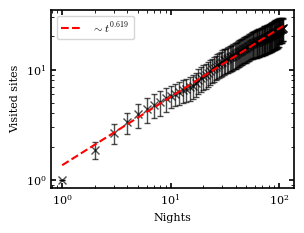

In [7]:
plot_power_law_fit(df_stats, alpha, intercept, "All years")
#plot_power_law_fit(df_stats, alpha, intercept, "All years", save_path = "../Plots/clusters.pdf")

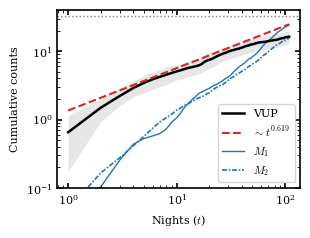

In [11]:
def plot_m1_m2_with_fit(df_counts, alpha, intercept, min_ids=50, savepath=None):
    from utilities import set_article_style
    set_article_style()
    
    # Calculate statistics across all cows
    stats = df_counts.groupby("time_step").agg(
        m_unique=("total_unique", "mean"), sd_unique=("total_unique", "std"),
        m_m1=("m1_accumulation", "mean"), sd_m1=("m1_accumulation", "std"),
        m_m2=("m2_accumulation", "mean"), sd_m2=("m2_accumulation", "std"),
        n=("id", "count")
    ).reset_index()

    stats = stats[stats["n"] >= min_ids]
    
    # Adjust figure size for RevTeX one-column width (approx 3.3 to 3.5 inches)
    plt.figure(figsize=(3.375, 2))

    plt.axhline(y=33, color="gray", linestyle=":", linewidth=1.0, zorder=0)

     # --- 1) Reference Cloud (Extremely subtle) ---
    # We use a very light gray so it's barely a "whisper" of the variance
    plt.fill_between(stats["time_step"], 
                     np.maximum(0.1, stats["m_unique"] - stats["sd_unique"]), 
                     stats["m_unique"] + stats["sd_unique"], 
                     color="0.9", lw=0, zorder=1)

    # --- 2) The Empirical Data (The "Black" Lines) ---
    # VUP (Total) - Solid Thin or different gray
    plt.plot(stats["time_step"], stats["m_unique"], color="black", ls="-", lw=1.8, label="VUP")

    # --- 3) The Theoretical Fit (The "Accent") ---
    # Instead of red, we use a deep Charcoal or Navy, or just a heavy dashed line
    x_data = stats["time_step"]
    x_fit = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 200)
    y_fit = np.exp(intercept) * x_fit**alpha
    
    # Using a dark, professional 'SlateBlue' or just a distinct 'Gray' dash
    plt.plot(x_fit, y_fit, color="#d62728", ls="--", lw=1.5, zorder=100, 
             label=fr'$\sim t^{{{alpha:.3f}}}$')

    # Most Visited (M1) - Solid Thick
    plt.plot(stats["time_step"], stats["m_m1"], color="#1f77b4", ls="-", lw=1.0, zorder=1, label=r"$M_1$")
    
    # Second Most (M2) - Dotted/Dashed
    plt.plot(stats["time_step"], stats["m_m2"], color="#1f77b4", ls=(0, (3, 1, 1, 1)), zorder=2, lw=1.2, label=r"$M_2$")
    

    # Formatting
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Nights ($t$)")
    plt.ylabel("Cumulative counts")

    plt.ylim(0.1, 40)
    
    # Legend: best to place outside or in a clear corner
    plt.legend(frameon=True, loc="lower right")
    
    import seaborn as sns
    sns.despine(top=False, right=False)

    if savepath: 
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

    return stats

# Example usage with your previously computed alpha/intercept
stats = plot_m1_m2_with_fit(df_m1_m2, alpha, intercept, savepath="../Plots/Article/Visited_M1M2.pdf")


In [12]:
# 1. Get the very last row of the filtered stats DataFrame
last_row = stats.iloc[-1]
final_t = last_row["time_step"]

# 2. Extract values and standard deviations
m1_val = last_row["m_m1"]
m1_std = last_row["sd_m1"]

m2_val = last_row["m_m2"]
m2_std = last_row["sd_m2"]

vup_val = last_row["m_unique"]
vup_std = last_row["sd_unique"]

# 3. Print out the results formatted nicely
print(f"--- Final Values at t = {final_t} ---")
print(f"M1 = {m1_val:.2f} ± {m1_std:.2f}")
print(f"M2 = {m2_val:.2f} ± {m2_std:.2f}")
print(f"VUP = {vup_val:.2f} ± {vup_std:.2f}")

--- Final Values at t = 109.0 ---
M1 = 24.18 ± 8.45
M2 = 15.56 ± 3.68
VUP = 16.27 ± 3.54
